# Step 1: Define the Goal

To compare  the performance of 3 regressions models (linear, lasso, and ridge on two sets of data) on 2 sets of data: log_cleaned_facebook_data.csv and original_cleaned_facebook_data.csv

# Step 2: Load the Data

## Load the data

Import packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Read the cleaned log CSV file and define the data frame as df_log

In [3]:
df_log = pd.read_csv('../data/log_cleaned_facebook_data.csv')
df = pd.read_csv('../data/original_cleaned_facebook_data.csv')

Define the Features and Target

In [4]:
X1 = df_log.drop(columns=['Total Interactions'])
y1 = df_log['Total Interactions']

X2 = df.drop(columns=['Total Interactions'])
y2 = df['Total Interactions']


# Step 3: Split the data into train and test

In [5]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

print(f"LOG Train: {X1_train.shape[0]} rows | Test: {X1_test.shape[0]} rows")


LOG Train: 399 rows | Test: 100 rows


In [6]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

print(f"ORIGINAL Train: {X1_train.shape[0]} rows | Test: {X1_test.shape[0]} rows")

ORIGINAL Train: 399 rows | Test: 100 rows


# Step 4: Scale the data

In [7]:
df_log.columns

Index(['Page total likes', 'Category', 'Post Month', 'Post Weekday',
       'Post Hour', 'Paid', 'Lifetime Post Total Reach',
       'Lifetime Post Total Impressions', 'Lifetime Engaged Users',
       'Lifetime Post Consumers', 'Lifetime Post Consumptions',
       'Lifetime Post Impressions by people who have liked your Page',
       'Lifetime Post reach by people who like your Page',
       'Lifetime People who have liked your Page and engaged with your post',
       'Total Interactions', 'Photo', 'Status', 'Video'],
      dtype='object')

In [8]:
continuous_features1 = ['Page total likes', 'Category', 'Post Month', 'Post Weekday',
       'Post Hour', 'Lifetime Post Total Reach',
       'Lifetime Post Total Impressions', 'Lifetime Engaged Users',
       'Lifetime Post Consumers', 'Lifetime Post Consumptions',
       'Lifetime Post Impressions by people who have liked your Page',
       'Lifetime Post reach by people who like your Page',
       'Lifetime People who have liked your Page and engaged with your post']
dummy_features1 = ['Paid', 'Photo', 'Status','Video']

scaler = StandardScaler()

X1_train_scaled = X1_train.copy()
X1_test_scaled = X1_test.copy()# Copies ALL columns: continuous + dummies intact

# Then ONLY overwrites continuous_features with scaled versions
scaler.fit(X1_train[continuous_features1])

#Overwrite 
X1_train_scaled[continuous_features1] = scaler.transform(X1_train[continuous_features1])
X1_test_scaled[continuous_features1] = scaler.transform(X1_test[continuous_features1])

X1_train_scaled.head()

,Page total likes,Category,Post Month,Post Weekday,Post Hour,Paid,Lifetime Post Total Reach,Lifetime Post Total Impressions,Lifetime Engaged Users,Lifetime Post Consumers,Lifetime Post Consumptions,Lifetime Post Impressions by people who have liked your Page,Lifetime Post reach by people who like your Page,Lifetime People who have liked your Page and engaged with your post,Photo,Status,Video
56,0.885314,-1.093262,1.036013,0.533067,0.784256,0.0,-0.106775,-0.091250,-0.742962,-1.141563,-1.100952,-0.427791,-0.421321,-0.774990,1,0,0
227,0.531727,-1.093262,0.199709,0.138358,0.629123,1.0,2.410046,2.727262,0.064881,0.019412,-0.004985,2.300272,1.763494,-0.106710,1,0,0
280,0.230009,0.288368,-0.075710,-1.845329,0.926963,0.0,-0.640039,-0.761805,0.121906,0.271736,0.012222,-0.805039,-0.679889,-0.235215,1,0,0
486,-2.553468,1.268651,-2.659634,-1.845329,0.926963,0.0,-0.236008,-0.325812,0.494089,0.632579,0.345147,-0.357910,-0.302594,-0.041708,1,0,0
220,0.544233,0.288368,0.442646,-1.845329,-0.776615,0.0,-0.851088,-0.864214,-0.600250,-0.603150,-0.673328,-0.733170,-0.729224,-0.592967,1,0,0


In [9]:
continuous_features2 = ['Page total likes', 'Category', 'Post Month', 'Post Weekday',
       'Post Hour', 'Lifetime Post Total Reach',
       'Lifetime Post Total Impressions', 'Lifetime Engaged Users',
       'Lifetime Post Consumers', 'Lifetime Post Consumptions',
       'Lifetime Post Impressions by people who have liked your Page',
       'Lifetime Post reach by people who like your Page',
       'Lifetime People who have liked your Page and engaged with your post']
dummy_features2 = ['Paid', 'Photo', 'Status','Video']

scaler = StandardScaler()

X2_train_scaled = X2_train.copy()
X2_test_scaled = X2_test.copy()# Copies ALL columns: continuous + dummies intact

# Then ONLY overwrites continuous_features with scaled versions
scaler.fit(X2_train[continuous_features2])

#Overwrite 
X2_train_scaled[continuous_features2] = scaler.transform(X2_train[continuous_features2])
X2_test_scaled[continuous_features2] = scaler.transform(X2_test[continuous_features2])

X2_train_scaled.head()

,Page total likes,Category,Post Month,Post Weekday,Post Hour,Paid,Lifetime Post Total Reach,Lifetime Post Total Impressions,Lifetime Engaged Users,Lifetime Post Consumers,Lifetime Post Consumptions,Lifetime Post Impressions by people who have liked your Page,Lifetime Post reach by people who like your Page,Lifetime People who have liked your Page and engaged with your post,Photo,Status,Video
56,0.941769,-1.049043,1.230644,0.410918,0.709827,0.0,-0.338994,-0.230540,-0.586278,-0.665499,-0.608951,-0.185230,-0.505488,-0.623738,1,0,0
227,0.522492,-1.049043,-0.011676,-0.078504,0.479940,1.0,3.728151,3.229223,-0.244730,-0.270096,-0.295114,1.096291,2.035937,-0.346377,1,0,0
280,0.180579,0.146866,-0.322256,-1.546770,0.939715,0.0,-0.456998,-0.310070,-0.210191,-0.115558,-0.287011,-0.212797,-0.584957,-0.412191,1,0,0
486,-2.383354,1.342775,-1.875155,-1.546770,0.939715,0.0,-0.374304,-0.265389,0.063239,0.175399,-0.100114,-0.178867,-0.461925,-0.310335,1,0,0
220,0.536974,0.146866,0.298904,-1.546770,-0.899384,0.0,-0.487497,-0.317742,-0.542145,-0.531211,-0.524144,-0.208322,-0.598026,-0.562625,1,0,0


Note that we put the Paid binary data into dummmy_features to avoid scaling with the rest of the features which aren't binary. We don't want to distory these variable's meanings by scaling them.

We then scale the data in two steps:
1. scaler.fit() is called on the training data to compute the mean and standard deivation for each continuous feature.
2. scaler.transform() is called on both the training data and the testing data to scale them according to the mean and standard deviation of the training data grabbed in previous step.

Critically, we're avoiding two common mistakes:
1. Not scaling the test and traing data on the same critical information: the mean and standard deviation of the training data.
2. Scaling on the whole data instead of the training data. This would cause data leakage meaning that the critical information from the mean and standar deviation of the test data would be used to scale the training data.


## Step 5: Build and Review Performance the Models

In [10]:
lr1 = LinearRegression()
lr1.fit(X1_train_scaled, y1_train)

y1_pred_lr = lr1.predict(X1_test_scaled)

print("LOG Linear Regression metrics")
print(f" R²:   {r2_score(y1_test, y1_pred_lr):.4f}")
print(f" MSE: {(mean_squared_error(y1_test, y1_pred_lr)):.4f}")
print(f" RMSE: {np.sqrt(mean_squared_error(y1_test, y1_pred_lr)):.4f}")

LOG Linear Regression metrics
 R²:   0.2702
 MSE: 51064.4079
 RMSE: 225.9744


In [11]:
print("LOG Model Dataset (Test Set):")
print(f"y1_test mean:    {np.mean(y1_test):.1f}")
print(f"y1_test median:  {np.median(y1_test):.1f}")
print(f"y1_test std:     {np.std(y1_test):.1f}")
print(f"y1_test back-transformed mean: {np.mean(np.exp(y1_test)):.1f}")

print("\nORIGINAL Model Dataset (Test Set):")
print(f"y2_test mean:    {np.mean(y2_test):.1f}")
print(f"y2_test median:  {np.median(y2_test):.1f}")
print(f"y2_test std:     {np.std(y2_test):.1f}")

print("\nFull Training Data:")
print(f"X1_train_scaled shape: {X1_train_scaled.shape}")
print(f"y1_train mean:         {np.mean(y1_train):.1f}")
print(f"y2_train mean:         {np.mean(y2_train):.1f}")


LOG Model Dataset (Test Set):
y1_test mean:    189.2
y1_test median:  117.5
y1_test std:     264.5
y1_test back-transformed mean: inf

ORIGINAL Model Dataset (Test Set):
y2_test mean:    189.2
y2_test median:  117.5
y2_test std:     264.5

Full Training Data:
X1_train_scaled shape: (399, 17)
y1_train mean:         218.1
y2_train mean:         218.1


/opt/miniconda3/envs/ds_class/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


R² of 0.27 means the input features explain ~27% of the variance in Total Interactions. According to Duke (https://people.duke.edu/~rnau/rsquared.htm), non-stationary metrics like Facebook data can be considered good around 0.25. Higher R² closer to 1 may look impressive but could be overfitted.

RMSE of 225.97 indicates that predictions deviate from actual Total Interactions by about ±226 units. For example, if the true value of a post interaction is 218.1 (training data mean), the predictions range -7.9 to 444.1 (clipped to 0).

Given:
- Absolute error = |predicted - actual|
- Relative error = absolute error ÷ actual value
- Percentage error = relative error × 100%

For prediction of 0:
- Absolute error = |0 - 218.1| = 218.1
- Relative error = 218.1 ÷ 218.1 = 1.00
- Percentage error = 100%

For prediction of 444.1:
- Absolute error = |444.1 - 218.1| = 226.0
- Relative error = 226.0 ÷ 218.1 ≈ 1.036
- Percentage error ≈ 104%

This means the model has ~100-104% average error around typical engagement levels.

This level of accuracy is reasonable for volatile marketing/social engagement data influenced by many unobserved factors.

Note: All calculations use original units (post back-transformation from log scale).


Plot saved as log_model_performance.png


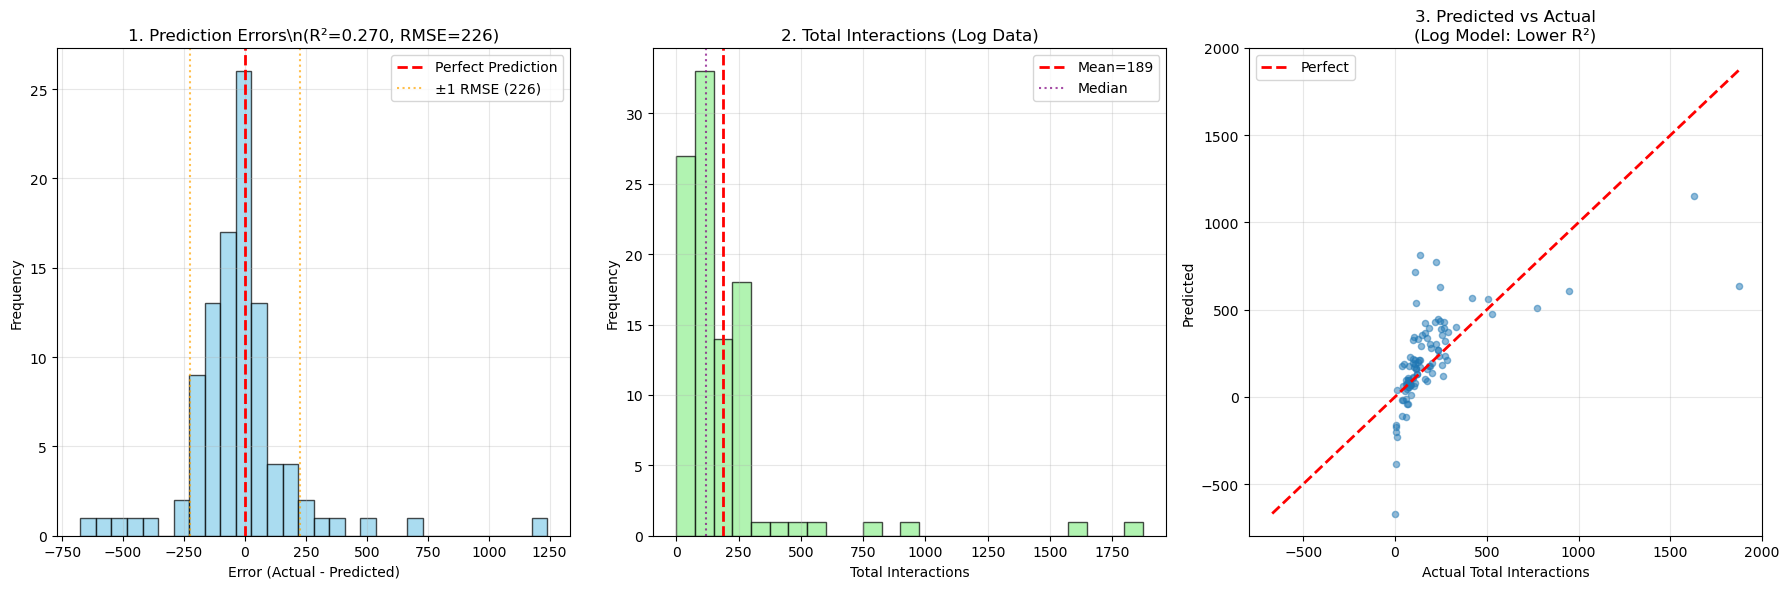

In [12]:
errors_log = y1_test - y1_pred_lr

# 3-panel plot
plt.figure(figsize=(18, 6))

# 1. Error distribution
plt.subplot(1, 3, 1)
plt.hist(errors_log, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
rmse_val = 225.97  # From provided metrics
plt.axvline(rmse_val, color='orange', linestyle=':', alpha=0.7, label=f'±1 RMSE ({rmse_val:.0f})')
plt.axvline(-rmse_val, color='orange', linestyle=':', alpha=0.7)
plt.title('1. Prediction Errors\\n(R²=0.270, RMSE=226)')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Data distribution (25 bins)
plt.subplot(1, 3, 2)
plt.hist(y1_test, bins=25, edgecolor='black', alpha=0.7, color='lightgreen')
plt.axvline(np.mean(y1_test), color='red', linestyle='--', linewidth=2, label=f'Mean={np.mean(y1_test):.0f}')
plt.axvline(np.median(y1_test), color='purple', linestyle=':', alpha=0.7, label='Median')
plt.title('2. Total Interactions (Log Data)')
plt.xlabel('Total Interactions')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Predicted vs Actual
plt.subplot(1, 3, 3)
plt.scatter(y1_test, y1_pred_lr, alpha=0.5, s=20)
min_val, max_val = min(y1_test.min(), y1_pred_lr.min()), max(y1_test.max(), y1_pred_lr.max())
plt.plot([min_val, max_val], [min_val, max_val], 'red', linestyle='--', linewidth=2, label='Perfect')
plt.title('3. Predicted vs Actual\n(Log Model: Lower R²)')
plt.xlabel('Actual Total Interactions')
plt.ylabel('Predicted')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('log_model_performance.png')
print("Plot saved as log_model_performance.png")


Graphs above:
1. The prediction error range based on RMSE - this is fairly wide
2. Logged distribution with mean and median
3. The line of best fit for predicted (y) vs. actual (x) target values

In [13]:
lr1 = LinearRegression()
lr1.fit(X1_train_scaled, y1_train)

# YOUR Facebook features (same 17 columns)
feature_names = ['Page total likes', 'Category', 'Post Month', 'Post Weekday',
       'Post Hour', 'Lifetime Post Total Reach',
       'Lifetime Post Total Impressions', 'Lifetime Engaged Users',
       'Lifetime Post Consumers', 'Lifetime Post Consumptions',
       'Lifetime Post Impressions by people who have liked your Page',
       'Lifetime Post reach by people who like your Page',
       'Lifetime People who have liked your Page and engaged with your post',
       'Paid', 'Photo', 'Status', 'Video']

# Print LOG model equation
print("\nLOG Model Equation:")
print(f"log(y) = {lr1.intercept_:.2f}")
for i, (name, coef) in enumerate(zip(feature_names, lr1.coef_)):
    sign = "+" if coef >= 0 else "-"
    print(f"  {sign} {abs(coef):.3f} × {name}")
print()





LOG Model Equation:
log(y) = 282.00
  + 236.342 × Page total likes
  - 25.836 × Category
  - 252.258 × Post Month
  - 0.754 × Post Weekday
  + 7.292 × Post Hour
  + 19.921 × Lifetime Post Total Reach
  + 137.777 × Lifetime Post Total Impressions
  - 156.898 × Lifetime Engaged Users
  + 1397.309 × Lifetime Post Consumers
  - 1215.318 × Lifetime Post Consumptions
  + 39.253 × Lifetime Post Impressions by people who have liked your Page
  + 138.122 × Lifetime Post reach by people who like your Page
  - 90.157 × Lifetime People who have liked your Page and engaged with your post
  - 93.658 × Paid
  - 76.270 × Photo
  - 34.339 × Status
  - 95.983 × Video



These coefficients seem extremely large. This definately could use either Ridge or Lasso regression to mitigate them.

In [14]:
lr2 = LinearRegression()
lr2.fit(X2_train_scaled, y2_train)

y2_pred_lr= lr2.predict(X2_test_scaled)

print("ORIGINAL Linear Regression metrics")
print(f" R²:   {r2_score(y2_test, y2_pred_lr):.4f}")
print(f" MSE: {(mean_squared_error(y2_test, y2_pred_lr)):.4f}")
print(f" RMSE: {np.sqrt(mean_squared_error(y2_test, y2_pred_lr)):.4f}")

ORIGINAL Linear Regression metrics
 R²:   0.9159
 MSE: 5886.9184
 RMSE: 76.7263


R² of 0.92 means the input features explain ~92% of the variance in Total Interactions. This is highly suspicious as it's an unusually high value for social or marketing engagement data. Such a strong fit often suggests overfitting or potential data leakage, since real-world engagement patterns typically contain far more unpredictability.

RMSE of 76.73 indicates that predictions deviate from actual Total Interactions by about ±77 units. For example, if the true value of a post interaction is 218.1 (training data mean), the predictions range 141.1 to 295.1.

Given:
- Absolute error = |predicted - actual|
- Relative error = absolute error ÷ actual value
- Percentage error = relative error × 100%

For prediction of 141.1:
- Absolute error = |141.1 - 218.1| = 77.0
- Relative error = 77.0 ÷ 218.1 ≈ 0.353
- Percentage error ≈ 35%

For prediction of 295.1:
- Absolute error = |295.1 - 218.1| = 77.0
- Relative error = 77.0 ÷ 218.1 ≈ 0.353
- Percentage error ≈ 35%

This means the model has ~35% average error around typical engagement levels.

Given that:
- A model can produce high R² with high % error if data spreads over a large range.
- A model can produce high R² with low % error if data is tightly clustered.

This moderate 35% error indicates the data spreads over a moderate range (not tightly clustered).


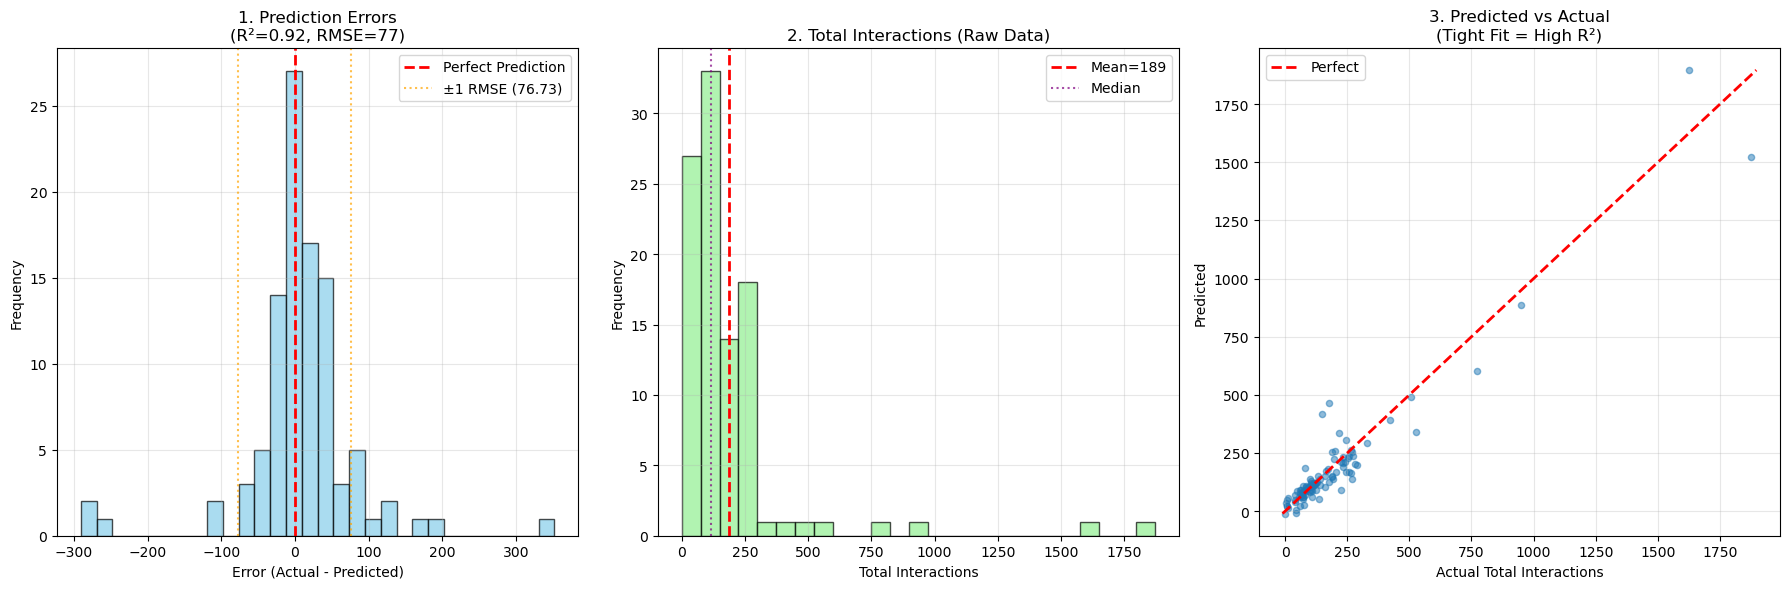

In [15]:
errors = y2_test - y2_pred_lr

# 3-panel demo of data spread + model performance
plt.figure(figsize=(18, 6))

# 1. Error distribution (unchanged)
plt.subplot(1, 3, 1)
plt.hist(errors, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.axvline(76.73, color='orange', linestyle=':', alpha=0.7, label='±1 RMSE (76.73)')
plt.axvline(-76.73, color='orange', linestyle=':', alpha=0.7)
plt.title('1. Prediction Errors\n(R²=0.92, RMSE=77)')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Data distribution (FIXED: bins=25)
plt.subplot(1, 3, 2)
plt.hist(y2_test, bins=25, edgecolor='black', alpha=0.7, color='lightgreen')  # Changed to 25 bins
plt.axvline(np.mean(y2_test), color='red', linestyle='--', linewidth=2, label=f'Mean={np.mean(y2_test):.0f}')
plt.axvline(np.median(y2_test), color='purple', linestyle=':', alpha=0.7, label='Median')
plt.title('2. Total Interactions (Raw Data)')
plt.xlabel('Total Interactions')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Predicted vs Actual (unchanged)
plt.subplot(1, 3, 3)
plt.scatter(y2_test, y2_pred_lr, alpha=0.5, s=20)
min_val, max_val = min(y2_test.min(), y2_pred_lr.min()), max(y2_test.max(), y2_pred_lr.max())
plt.plot([min_val, max_val], [min_val, max_val], 'red', linestyle='--', linewidth=2, label='Perfect')
plt.title('3. Predicted vs Actual\n(Tight Fit = High R²)')
plt.xlabel('Actual Total Interactions')
plt.ylabel('Predicted')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Graphs above:
1. The prediction error range based on RMSE - this is fairly wide
2. Logged distribution with mean and median
3. The line of best fit for predicted (y) vs. actual (x) target values

In [16]:
# Feature names
feature_names = ['Page total likes', 'Category', 'Post Month', 'Post Weekday',
       'Post Hour', 'Lifetime Post Total Reach',
       'Lifetime Post Total Impressions', 'Lifetime Engaged Users',
       'Lifetime Post Consumers', 'Lifetime Post Consumptions',
       'Lifetime Post Impressions by people who have liked your Page',
       'Lifetime Post reach by people who like your Page',
       'Lifetime People who have liked your Page and engaged with your post',
       'Paid', 'Photo', 'Status','Video']

# Print full equation (handles long names)
print("\nORIGINAL Model Equation:")
print(f"y =", f"{lr2.intercept_:.2f}")
for i, (name, coef) in enumerate(zip(feature_names, lr2.coef_)):
    sign = "+" if coef >= 0 else "-"
    print(f"  {sign} {abs(coef):.3f} × {name}")
print()

y2_pred_lr = lr2.predict(X2_test_scaled)



ORIGINAL Model Equation:
y = 245.13
  + 25.890 × Page total likes
  - 4.143 × Category
  - 43.788 × Post Month
  + 1.826 × Post Weekday
  - 6.914 × Post Hour
  - 3.665 × Lifetime Post Total Reach
  - 67.691 × Lifetime Post Total Impressions
  + 104.018 × Lifetime Engaged Users
  + 1564.951 × Lifetime Post Consumers
  - 1394.757 × Lifetime Post Consumptions
  + 12.696 × Lifetime Post Impressions by people who have liked your Page
  - 79.684 × Lifetime Post reach by people who like your Page
  - 19.842 × Lifetime People who have liked your Page and engaged with your post
  + 32.949 × Paid
  - 29.021 × Photo
  - 30.706 × Status
  + 118.830 × Video



These coefficients are also still very large. Each weights too heavily likely causing multicollinearity.

In [17]:
ridge1 = Ridge(alpha=3) 
ridge1.fit(X1_train_scaled, y1_train)

y1_pred_ridge = ridge1.predict(X1_test_scaled)

print("LOG RIDGE REGRESSION (alpha=3)")
print(f" R²:   {r2_score(y1_test, y1_pred_ridge):.4f}")
print(f" MSE: {(mean_squared_error(y1_test, y1_pred_ridge)):.4f}")
print(f" RMSE: {np.sqrt(mean_squared_error(y1_test, y1_pred_ridge)):.4f}")

LOG RIDGE REGRESSION (alpha=3)
 R²:   0.4503
 MSE: 38457.2549
 RMSE: 196.1052


Experimenting with alpha:

| α Value | R² Score |
|-------------|----------|
| 0.00        | 0.2702     |
| 0.50        | 0.3797     |
| 1.00        | 0.4213     |
| 2.00        | 0.4470     |
| 3.00        | 0.4503     |
| 4.00        | 0.4480     |
| 5.00        | 0.4443     |
| 10.00       | 0.4277     |
| 500.00      | 0.3976     |
| 5000.00      | 0.2365     |

Our R² improved from 0.27 to 0.45 with alpha of 3 (from linear to Ridge)

Ridge is penalizing large coefficients which likely are overfitting or multicollinearity. As the alpha value increases, this penalty goes up which effectively mitigates large coefficients that were causing overfitting/multicularity; this increases the R². However, after a certain point (in this case, alpha of 3), it starts to negatively impact the performance of the model's abilty to predict accurate outcomes. 

Since Ridge shinks coefficients towards zero, but never exactly to zero, while Lasso does, I would be curious how much Lasso would perform better. 

In [18]:
# Print full equation 
print("\nLOG RIDGE Model Equation (alpha=3):")
print(f"log(y) = {ridge1.intercept_:.2f}")
for i, (name, coef) in enumerate(zip(feature_names, ridge1.coef_)):
    sign = "+" if coef >= 0 else "-"
    print(f"  {sign} {abs(coef):.3f} × {name}")
print()

y1_pred_ridge = ridge1.predict(X1_test_scaled)


LOG RIDGE Model Equation (alpha=3):
log(y) = 206.91
  + 75.562 × Page total likes
  + 10.163 × Category
  - 56.732 × Post Month
  - 4.667 × Post Weekday
  + 7.598 × Post Hour
  + 29.583 × Lifetime Post Total Reach
  + 105.570 × Lifetime Post Total Impressions
  - 42.709 × Lifetime Engaged Users
  + 623.753 × Lifetime Post Consumers
  - 564.236 × Lifetime Post Consumptions
  - 25.159 × Lifetime Post Impressions by people who have liked your Page
  - 9.975 × Lifetime Post reach by people who like your Page
  + 42.421 × Lifetime People who have liked your Page and engaged with your post
  + 71.515 × Paid
  + 19.463 × Photo
  - 133.688 × Status
  - 71.825 × Video



We can see the weight of each coefficient has shrank. 

In [19]:
ridge2 = Ridge(alpha=4) 
ridge2.fit(X2_train_scaled, y2_train)

y2_pred_ridge = ridge2.predict(X1_test_scaled)

print("ORIGINAL RIDGE REGRESSION (α=4)")
print(f"  R²:   {r2_score(y2_test, y2_pred_ridge):.4f}")
print(f"  MSE: {(mean_squared_error(y2_test, y1_pred_ridge)):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y2_test, y1_pred_ridge)):.4f}")

ORIGINAL RIDGE REGRESSION (α=4)
  R²:   0.4705
  MSE: 38457.2549
  RMSE: 196.1052


Experimenting with alpha:

| α Value | R² Score |
|-------------|----------|
| 0.00        | 0.3311     |
| 0.50        | 0.3937    |
| 1.00        | 0.4277     |
| 2.00        | 0.4588     |
| 3.00        | 0.4690     |
| 4.00        | 0.4705     |
| 5.00        | 0.4681     |
| 10.00       | 0.4415     |
| 500.00      | 0.3619     |
| 5000.00      | 0.2442     |

Our R² decreased from 0.91 to 0.47 with alpha of 4 (from linear to Ridge).

Like the case above, alpha hits a ceiling at a certain point (4 in this case). 

Since we suspected 0.91 was artificially high due to overfitting and that this R² is nearly identical to that of the log transformed data, I believe that the ridge regression corrected the overfitting and produced a more reasonable and appropriate model.

In [20]:
# Print full equation 
print("\nORIGINAL RIDGE Model Equation (alpha=4):")
print(f"y = {ridge2.intercept_:.2f}")
for i, (name, coef) in enumerate(zip(feature_names, ridge2.coef_)):
    sign = "+" if coef >= 0 else "-"
    print(f"  {sign} {abs(coef):.3f} × {name}")
print()

y2_pred_ridge = ridge2.predict(X2_test_scaled)  # Fixed: X2_test_scaled


ORIGINAL RIDGE Model Equation (alpha=4):
y = 202.20
  + 9.951 × Page total likes
  + 24.855 × Category
  - 2.439 × Post Month
  - 1.625 × Post Weekday
  - 3.527 × Post Hour
  + 7.800 × Lifetime Post Total Reach
  + 58.024 × Lifetime Post Total Impressions
  - 30.499 × Lifetime Engaged Users
  + 968.718 × Lifetime Post Consumers
  - 850.286 × Lifetime Post Consumptions
  - 16.584 × Lifetime Post Impressions by people who have liked your Page
  + 7.716 × Lifetime Post reach by people who like your Page
  + 20.011 × Lifetime People who have liked your Page and engaged with your post
  + 68.841 × Paid
  + 27.438 × Photo
  - 97.276 × Status
  - 18.308 × Video



This equation also shows shrinking of coefficients.

In [21]:
lasso1 = Lasso(alpha=3) 
lasso1.fit(X1_train_scaled, y1_train)

y1_pred_lasso = lasso1.predict(X1_test_scaled)

print("LOG LASSO REGRESSION (α=3)")
print(f" R²:   {r2_score(y1_test, y1_pred_lasso):.4f}")
print(f" MSE: {(mean_squared_error(y1_test, y1_pred_lasso)):.4f}")
print(f" RMSE: {np.sqrt(mean_squared_error(y1_test, y1_pred_lasso)):.4f}")

LOG LASSO REGRESSION (α=3)
 R²:   0.4943
 MSE: 35382.8994
 RMSE: 188.1034


Experimenting with alpha:

| α Value | R² Score |
|-------------|----------|
| 0.00        | 0.2713     |
| 0.50        | 0.4134    |
| 1.00        | 0.4621     |
| 2.00        | 0.4865     |
| 3.00        | 0.4943     |
| 4.00        | 0.4912     |
| 5.00        | 0.4859     |
| 10.00       | 0.4074     |
| 500.00      | -0.0119    |
| 5000.00      | -0.0119    |

Our R² improved from 0.27 to 0.4943 with alpha of 3 (from linear to Lasso). This is actually a slight improvement from 0.4705 from Ridge! It seems like Lasso's ability to completely eliminate certain coefficients is helping improve the performance of the model.

Like the case of Ridge, Lasso's alpha hits a ceiling at a certain point (3 in this case). 

When it become 500, R² actually becomes negative, very close to 0. Meaning Lasso eliminated all predictive features. At this point, the model now predicts the average Total Interactions (~606) for every post. Since Lasso's heavy regularization creates more error than even guessing the mean, R² drops negative.

In [22]:
#Print full equation (original style)
print("\nLOG LASSO Model Equation (alpha=3):")
print(f"log(y) = {lasso1.intercept_:.2f}")
for i, (name, coef) in enumerate(zip(feature_names, lasso1.coef_)):
    if abs(coef) < 1e-10:  # Skip zeroed features
        print(f"  0.000 × {name} (dropped)")
    else:
        sign = "+" if coef >= 0 else "-"
        print(f"  {sign} {abs(coef):.3f} × {name}")
print()

y1_pred_lasso = lasso1.predict(X1_test_scaled)




LOG LASSO Model Equation (alpha=3):
log(y) = 218.66
  + 3.362 × Page total likes
  0.000 × Category (dropped)
  0.000 × Post Month (dropped)
  - 0.527 × Post Weekday
  + 3.842 × Post Hour
  + 16.203 × Lifetime Post Total Reach
  + 37.322 × Lifetime Post Total Impressions
  0.000 × Lifetime Engaged Users (dropped)
  + 909.730 × Lifetime Post Consumers
  - 795.347 × Lifetime Post Consumptions
  0.000 × Lifetime Post Impressions by people who have liked your Page (dropped)
  0.000 × Lifetime Post reach by people who like your Page (dropped)
  + 31.128 × Lifetime People who have liked your Page and engaged with your post
  0.000 × Paid (dropped)
  0.000 × Photo (dropped)
  - 54.753 × Status
  0.000 × Video (dropped)



Each coefficient's weight is much lighter compared to that of Ridge. Lasso eliminated 6 features: `Category`, `Post Month`, `Lifetime Engaged Users`, `Paid`, `Photo`, and `Video`.

In [23]:
lasso2 = Lasso(alpha=2) 
lasso2.fit(X2_train_scaled, y2_train)

y2_pred_lasso = lasso2.predict(X2_test_scaled)

print("ORIGINAL LASSO REGRESSION (alpha=2)")
print(f"  R²:   {r2_score(y2_test, y2_pred_lasso):.4f}")
print(f"  MSE: {(mean_squared_error(y2_test, y2_pred_lasso)):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y2_test, y2_pred_lasso)):.4f}")

ORIGINAL LASSO REGRESSION (alpha=2)
  R²:   0.9526
  MSE: 3315.3640
  RMSE: 57.5792


Experimenting with alpha:

| Alpha Value | R² Score |
|-------------|----------|
| 0.00        | 0.9159     |
| 0.50        | 0.9442   |
| 1.00        | 0.9500    |
| 2.00        | 0.9526     |
| 3.00        | 0.9523     |
| 4.00        | 0.9500    |
| 5.00        | 0.9454     |
| 10.00       | 0.9242    |
| 500.00      | -0.0119    |
| 5000.00      | -0.0119    |

Our R² improved from 0.92 to 0.95 with alpha of 2 (from linear to Lasso). Compared to Ridge with alpha of 4 (0.47), this is much higher. This improvement likely actually corrected overfitting through regularization.  

Like the cases before, Lasso's alpha hits a ceiling at a certain point (2 in this case). It also has the negative R² value like the Lasso of log from above. 


In [24]:
# Print full equation 
print("\nORIGINAL LASSO Model Equation (alpha=2):")
print(f"y = {lasso2.intercept_:.2f}")
for i, (name, coef) in enumerate(zip(feature_names, lasso2.coef_)):
    if abs(coef) < 1e-10:  # Skip zeroed features
        print(f"  0.000 × {name} (dropped)")
    else:
        sign = "+" if coef >= 0 else "-"
        print(f"  {sign} {abs(coef):.3f} × {name}")
print()

y2_pred_lasso = lasso2.predict(X2_test_scaled)



ORIGINAL LASSO Model Equation (alpha=2):
y = 218.10
  0.000 × Page total likes (dropped)
  + 2.127 × Category
  - 7.918 × Post Month
  0.000 × Post Weekday (dropped)
  - 1.695 × Post Hour
  0.000 × Lifetime Post Total Reach (dropped)
  0.000 × Lifetime Post Total Impressions (dropped)
  0.000 × Lifetime Engaged Users (dropped)
  + 1415.147 × Lifetime Post Consumers
  - 1248.099 × Lifetime Post Consumptions
  + 1.157 × Lifetime Post Impressions by people who have liked your Page
  - 0.182 × Lifetime Post reach by people who like your Page
  - 8.624 × Lifetime People who have liked your Page and engaged with your post
  + 20.773 × Paid
  0.000 × Photo (dropped)
  0.000 × Status (dropped)
  0.000 × Video (dropped)



Each coefficient's weight is much lighter compared to that of Ridge as well. Lasso eliminated 8 features: `Page total likes`, `Post Weekday`, `Lifetime Post Total Reach`, `Lifetime Post Total Impressions`, `Lifetime Engaged Users`, `Photo`, `Status`, and `Video`.

In [25]:
# Create coefficient series
lasso_coefs1 = pd.Series(lasso1.coef_, index=feature_names)
lasso_coefs2 = pd.Series(lasso2.coef_, index=feature_names)

# 3-column table
comparison = pd.DataFrame({
    'Feature': feature_names,
    'Log Lasso α=3 (R²=0.4943)': lasso_coefs1.round(3),
    'Original Lasso α=2 (R²=0.9526)': lasso_coefs2.round(3)
})

# Mark zeros
for col in comparison.columns[1:]:
    comparison[col] = comparison[col].apply(
        lambda x: '0.000 (dropped)' if abs(x) < 1e-10 else x
    )

# Sort by ABSOLUTE last column (highest impact first)
comparison['abs_original_coef'] = pd.to_numeric(comparison['Original Lasso α=2 (R²=0.9526)'], errors='coerce').abs()
comparison_sorted = comparison.sort_values('abs_original_coef', ascending=False).drop('abs_original_coef', axis=1)

print("Lasso Coefficients: Sorted by |Original Lasso| (Highest Impact)")
print(comparison_sorted.to_string(index=False))


Lasso Coefficients: Sorted by |Original Lasso| (Highest Impact)
                                                            Feature Log Lasso α=3 (R²=0.4943) Original Lasso α=2 (R²=0.9526)
                                            Lifetime Post Consumers                    909.73                       1415.147
                                         Lifetime Post Consumptions                  -795.347                      -1248.099
                                                               Paid           0.000 (dropped)                         20.773
Lifetime People who have liked your Page and engaged with your post                    31.128                         -8.624
                                                         Post Month           0.000 (dropped)                         -7.918
                                                           Category           0.000 (dropped)                          2.127
                                                          Pos

- Both Lasso models identify `Lifetime Post Consumers` and `Lifetime Post Consumptions` as dominant drivers.
    - Lifetime Post Consumers: Each additional person clicking anywhere (links, expands, photos, videos) boosts Total Interactions by ~1415 units in the original model. Clear positive engagement signal.
    - Lifetime Post Consumptions: As more clicks happen, people are less likely to engage with the post. 
This means that the first clicks from the users are extremely positively associated with increase of Total Interactions. Hwoever, the subsequent clicks by these users actually have a negative effect on the Total Interactions. Perhaps they click like then unlike the post. 

- Paid: Retained only in Original Lasso. Paid posts appear to benefit interactions. Perhaps the creator put more effort into making the post higher quality since it's paid. Not that paying causes more interactions.
​
- Both models identified and dropped irrelevant Lifetime metrics: `Lifetime Engaged Users`, `Photo`, and `Video`. `Lifetime Engaged Users` is very similar to `Lifetime Post Consumers`, the only difference being the first one is unique users so this could be a sign of multicollinearity that is being dropped by the model. It's bit surprising to see that it doesn't matter if the post is a `Photo` or `Video` as conventional social media marketing wisdom goes against that. Something worth exploring more. 
​
- Timing effects: Post Month (-7.9), Post Hour (-1.7) reveal potentially optimal windows. Perhaps you could intrepet this to mean that we should post earlier in the year and earlier in the day. However, this doens't quite capture the likely fluctuations in the performance based on the mont hand time of posting. Perhaps, a better way to incorporate these features in the model would be do turn them into dummy data to capture that granurity.  

Actionable recommendation based on the original Lasso model: Create content that users are likely to click. Potentially pay for it and adjust timing accordingly. This may result in posts that maximizes Total Interactions through as mentioned before, furthure analysis would be helpful.

​


Later, we can use Ridge_CV and Lasso_CV to determine the best alpha for the respective models.

## Step 6: Check if Models are Overfitting

In [26]:
print("LOG Train R²:")
print(f"  Linear Regression: {r2_score(y1_train, lr1.predict(X1_train_scaled)):.4f}")
print(f"  Ridge:             {r2_score(y1_train, ridge1.predict(X1_train_scaled)):.4f}")
print(f"  Lasso:             {r2_score(y1_train, lasso1.predict(X1_train_scaled)):.4f}")

print("\nLOG Test R²:")
print(f"  Linear Regression: {r2_score(y1_test, y1_pred_lr):.4f}")
print(f"  Ridge:             {r2_score(y1_test, y1_pred_ridge):.4f}")
print(f"  Lasso:             {r2_score(y1_test, y1_pred_lasso):.4f}")

LOG Train R²:
  Linear Regression: 0.4576
  Ridge:             0.4185
  Lasso:             0.4334

LOG Test R²:
  Linear Regression: 0.2702
  Ridge:             0.4503
  Lasso:             0.4943


Linear regression for log data performed worse in test compared to training by 18%. Meaning that it's likely overfitting to the training data. Ridge and Lasso on the hand, actually improved by small margins. They're less likely to be overfitted. 

In [27]:
print("ORIGINAL Train R²:")
print(f"  Linear Regression: {r2_score(y2_train, lr2.predict(X2_train_scaled)):.4f}")
print(f"  Ridge:             {r2_score(y2_train, ridge2.predict(X2_train_scaled)):.4f}")
print(f"  Lasso:             {r2_score(y2_train, lasso2.predict(X2_train_scaled)):.4f}")

print("\nORIGINAL Test R²:")
print(f"  Linear Regression: {r2_score(y2_test, y2_pred_lr):.4f}")
print(f"  Ridge:             {r2_score(y2_test, y2_pred_ridge):.4f}")
print(f"  Lasso:             {r2_score(y2_test, y2_pred_lasso):.4f}")

ORIGINAL Train R²:
  Linear Regression: 0.9725
  Ridge:             0.9102
  Lasso:             0.9659

ORIGINAL Test R²:
  Linear Regression: 0.9159
  Ridge:             0.8901
  Lasso:             0.9526


All models performed worse for the original data but not by much. Meaning that there isn't as much overfitting compared to the log data.

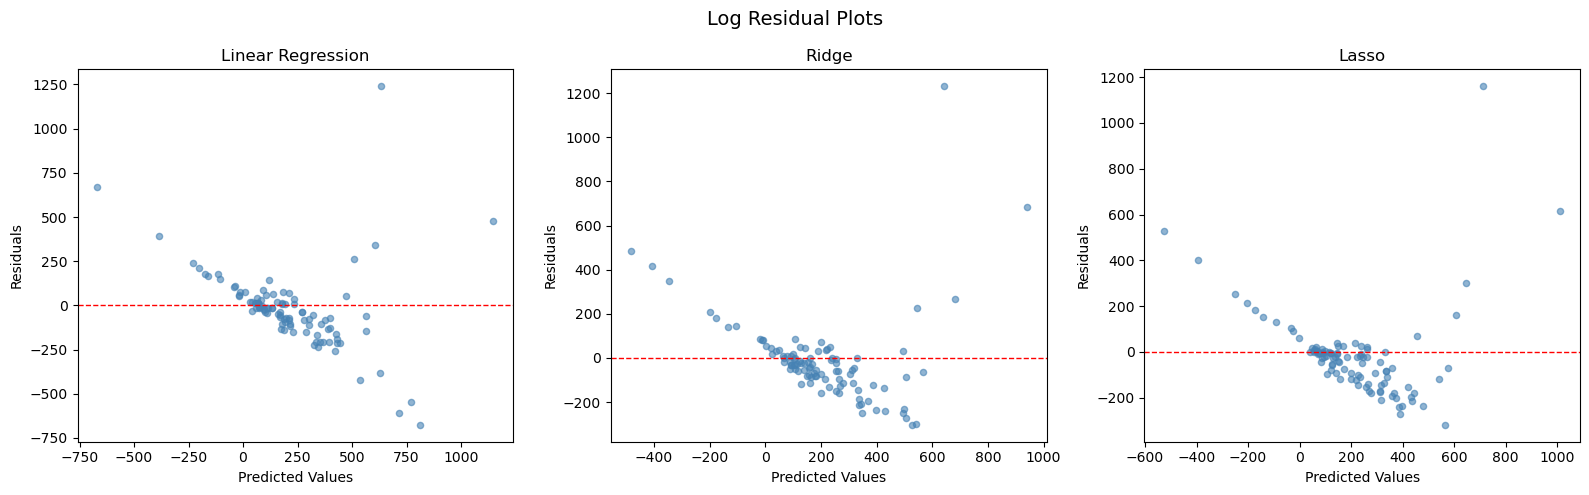

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = {
    'Linear Regression': y1_pred_lr,
    'Ridge': y1_pred_ridge,
    'Lasso': y1_pred_lasso
}

for ax, (name, y1_pred) in zip(axes, models.items()):
    residuals = y1_test - y1_pred
    ax.scatter(y1_pred, residuals, alpha=0.6, color='steelblue', s=20)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Predicted Values')
    ax.set_ylabel('Residuals')
    ax.set_title(name)

plt.suptitle('Log Residual Plots', fontsize=14)
plt.tight_layout()
plt.show()

The residuals show a clear downward pattern. This means that the linearity assumption has not been satisfied; the errors do not apppear to be random. Perhaps reducing the outliers would create a more scattered spread across both lines.

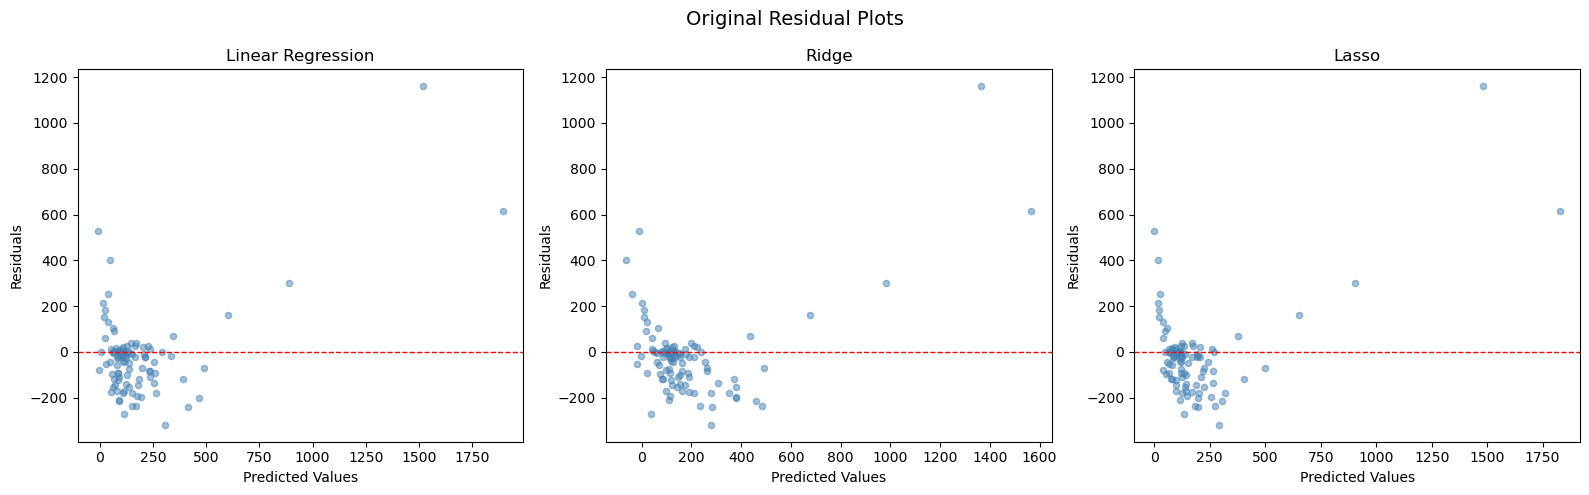

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = {
    'Linear Regression': y2_pred_lr,
    'Ridge': y2_pred_ridge,
    'Lasso': y2_pred_lasso
}

for ax, (name, y2_pred) in zip(axes, models.items()):
    residuals = y2_test - y1_pred
    ax.scatter(y2_pred, residuals, alpha=0.5, color='steelblue', s=20)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Predicted Values')
    ax.set_ylabel('Residuals')
    ax.set_title(name)

plt.suptitle('Original Residual Plots', fontsize=14)
plt.tight_layout()
plt.show()

The residuals here are also not randomly distributed. They are clustered around the 200's. Again, I think removing the outliers would help. These significant positive outliers are bringing the average up and most of the sample points have errors that are negative. 

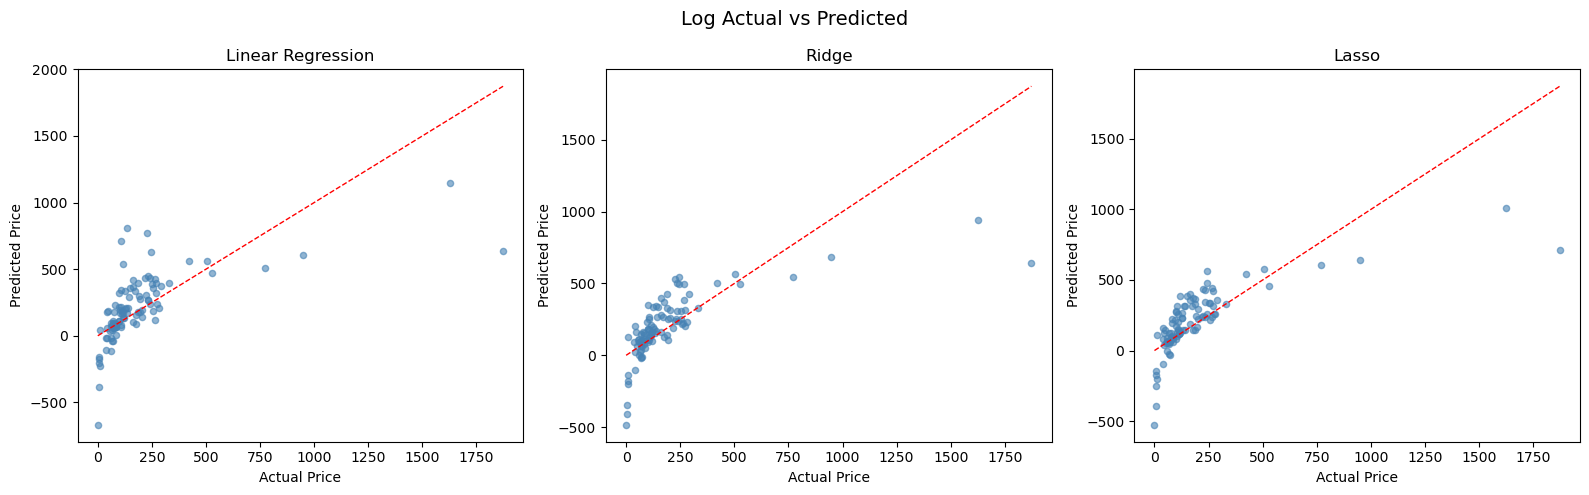

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, y1_pred) in zip(axes, models.items()):
    ax.scatter(y1_test, y1_pred, alpha=0.6, color='steelblue', s=20)
    ax.plot([y1_test.min(), y1_test.max()],
            [y1_test.min(), y1_test.max()],
            color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.set_title(name)

plt.suptitle('Log Actual vs Predicted', fontsize=14)
plt.tight_layout()
plt.show()

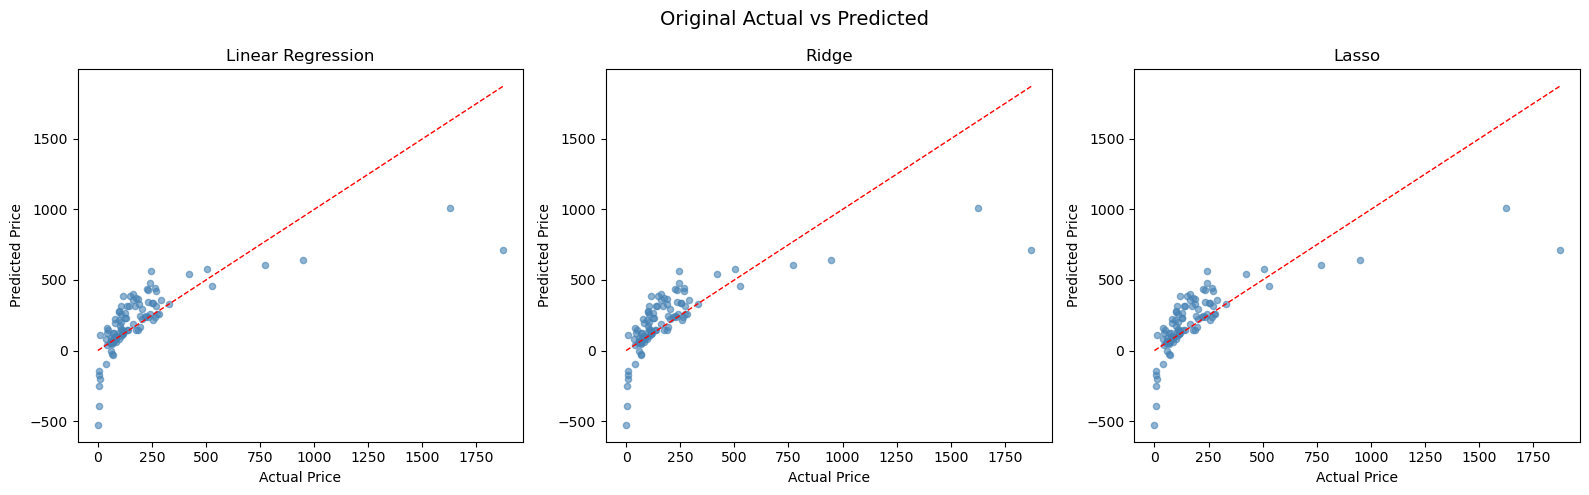

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, y2_pred) in zip(axes, models.items()):
    ax.scatter(y2_test, y1_pred, alpha=0.6, color='steelblue', s=20)
    ax.plot([y2_test.min(), y2_test.max()],
            [y2_test.min(), y2_test.max()],
            color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.set_title(name)

plt.suptitle('Original Actual vs Predicted', fontsize=14)
plt.tight_layout()
plt.show()

Graphs for both log and original data appear to show the same general pattern. None of the lines tug to the actual data effectively. Again, I believe the outliers are to blame. 

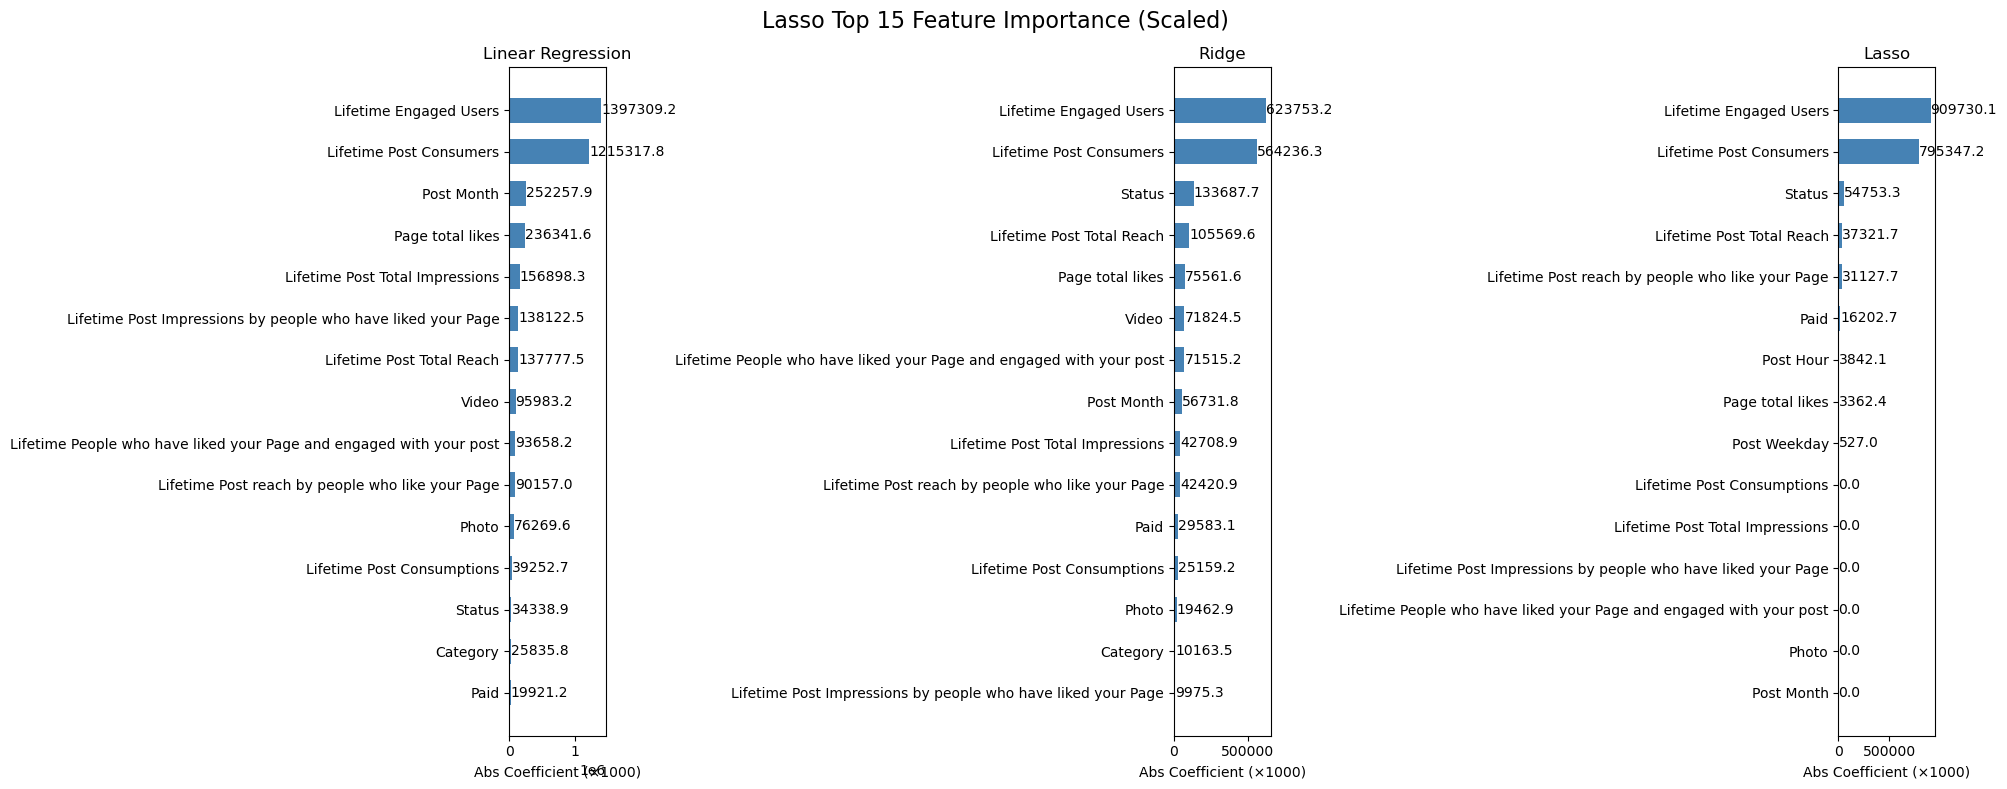

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))  # Wider/taller

coef_data = {
    'Linear Regression': lr1.coef_ * 1000,  # x1000 for visibility
    'Ridge': ridge1.coef_ * 1000,
    'Lasso': lasso1.coef_ * 1000
}

for ax, (name, coefs) in zip(axes, coef_data.items()):
    abs_coefs = pd.Series(np.abs(coefs), index=X1_train.columns).sort_values(ascending=True)
    top15 = abs_coefs[-15:]  # Top 15
    bars = ax.barh(top15.index, top15.values, color='steelblue', height=0.6)  # Thicker bars
    ax.bar_label(bars, fmt='%.1f')  # Add values on bars
    ax.set_xlabel('Abs Coefficient (×1000)')
    ax.set_title(name)

plt.suptitle('Lasso Top 15 Feature Importance (Scaled)', fontsize=16)
plt.tight_layout()
plt.show()


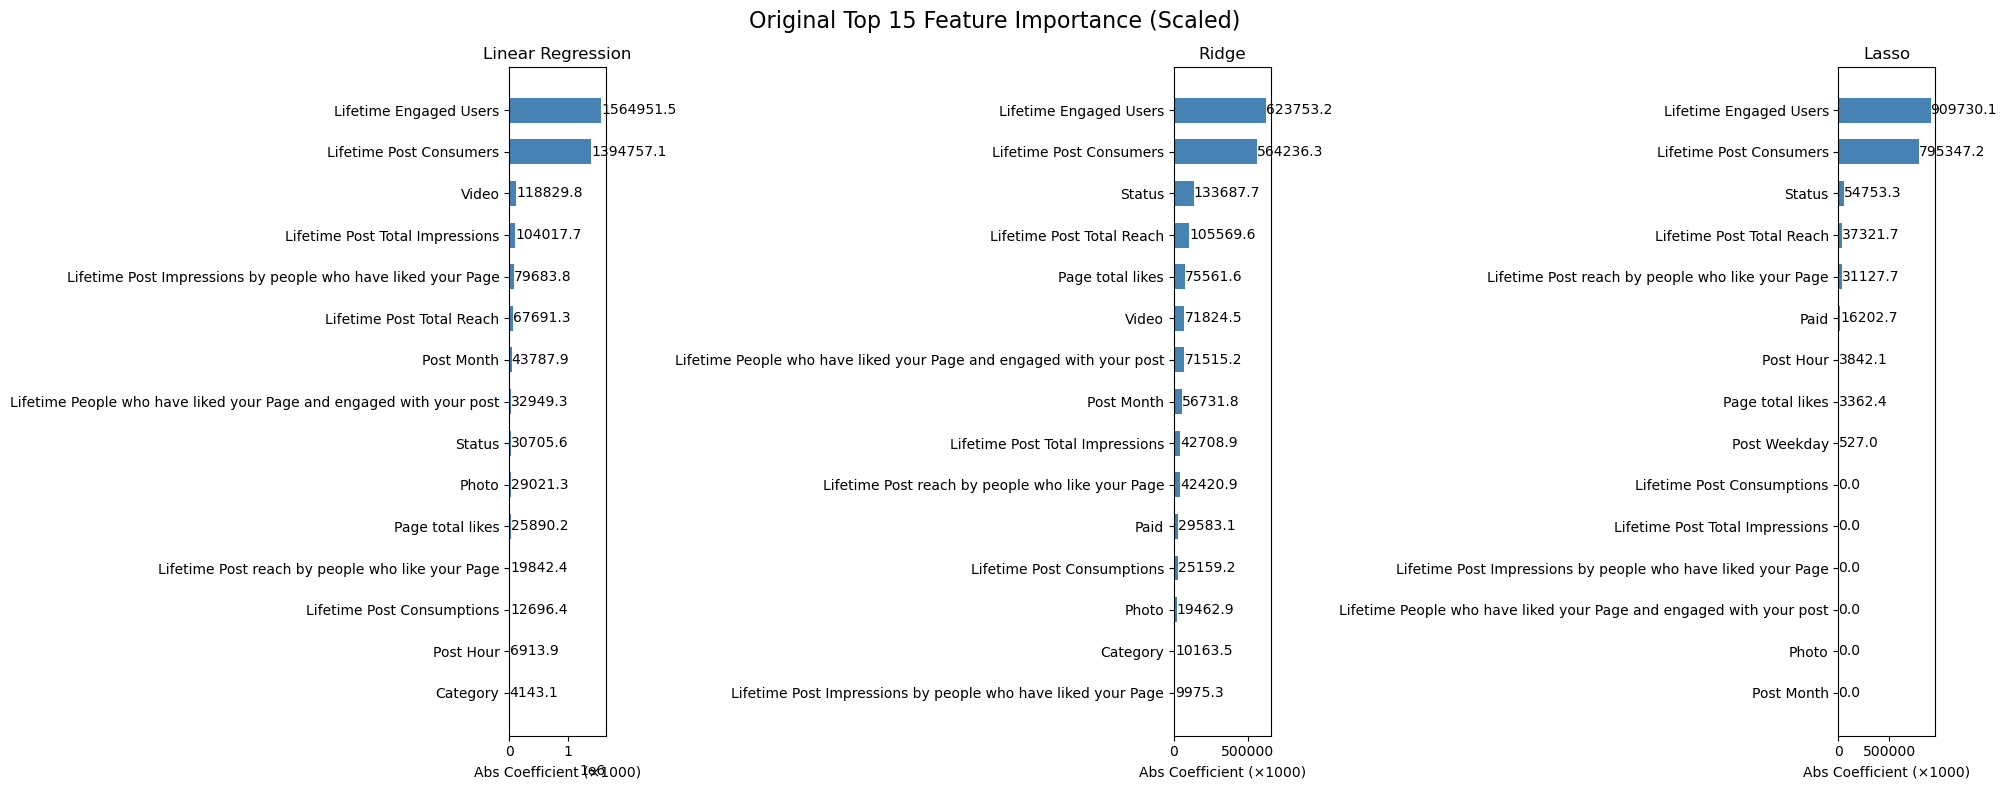

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))  # Wider/taller

coef_data = {
    'Linear Regression': lr2.coef_ * 1000,  # x1000 for visibility
    'Ridge': ridge1.coef_ * 1000,
    'Lasso': lasso1.coef_ * 1000
}

for ax, (name, coefs) in zip(axes, coef_data.items()):
    abs_coefs = pd.Series(np.abs(coefs), index=X2_train.columns).sort_values(ascending=True)
    top15 = abs_coefs[-15:]  # Top 15
    bars = ax.barh(top15.index, top15.values, color='steelblue', height=0.6)  # Thicker bars
    ax.bar_label(bars, fmt='%.1f')  # Add values on bars
    ax.set_xlabel('Abs Coefficient (×1000)')
    ax.set_title(name)

plt.suptitle('Original Top 15 Feature Importance (Scaled)', fontsize=16)
plt.tight_layout()
plt.show()


Across all models (for both log and original data), there is a clear trend of `Lifetime Engaged Users` and `Lifetime Post Consumers` being the dominant factors. Scaling the data has shown greater impact of `Status`, `Video `, and  `Post Month` in respective models.

## Notebook Summary

# Facebook Post Interaction Analysis Summary

**Overview**: Analyzed Facebook post data to predict Total Interactions using regression models on original and log-transformed datasets.

## Data
- **Features** (17): Page total likes, Post Month, Lifetime Post Consumers, post types (Photo/Status/Video), etc.
- **Target**: Total Interactions (comments + likes + shares)
- **Key EDA**: Right-skewed distributions → log transformation applied

## Model Performance

| Model | Log Data R² | Original R² | Key Insight |
|-------|-------------|-------------|-------------|
| Linear | 0.27 | 0.92 | Overfits due to multicollinearity |
| Ridge | 0.45 | 0.47 | Penalizes extremes, realistic fit |
| **Lasso** | **0.49** | **0.95** | **Best: feature selection + regularization** |

## Key Findings
- Lifetime Post Consumers (+1415) and Lifetime Post Consumptions (-1248) drive Total Interactions most strongly. More consumer clicks correlate with higher engagement, while excessive clicks reduce it.
- Post timing shows small effects: Month coefficient = -7.9, Hour coefficient = -1.7. Earlier posting months and hours may perform slightly better though further analysis is needed.
- Paid posts retained (+20.8). Paid status correlates with more interactions, likely due to increased creator effort rather than payment itself.
- Multicollinearity addressed: Lifetime Engaged Users dropped as it overlaps with Lifetime Post Consumers. Other variables were also dropped.

Recommendation: Prioritize clickable content creation, optimize posting timing, and consider paid boosts for higher-effort posts.